In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor

In [2]:
df = pd.read_csv('user_nutritional_data(1).csv')
df.head()

,Gender,Age,Height,Weight,BMR,Calories
0,0,29,165,101.0,1901.25,2281.502
1,1,25,165,53.0,1275.25,2422.978
2,0,23,170,70.0,1652.50,1983.000
3,0,22,168,112.0,2065.00,2478.000
4,0,19,175,67.0,1673.75,2594.313


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gender    2182 non-null   int64  
 1   Age       2182 non-null   int64  
 2   Height    2182 non-null   int64  
 3   Weight    2182 non-null   float64
 4   BMR       2182 non-null   float64
 5   Calories  2182 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 102.4 KB


In [4]:
df.describe()

,Gender,Age,Height,Weight,BMR,Calories
count,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000
mean,0.420257,26.752062,162.763520,73.814207,1556.891155,2002.868384
std,0.493713,8.425983,10.123945,20.837370,270.809953,448.255305
min,0.000000,15.000000,122.000000,35.000000,861.500000,1033.800000
25%,0.000000,22.000000,157.000000,56.000000,1350.000000,1659.298000
50%,0.000000,24.000000,163.000000,72.000000,1548.250000,1943.400000
75%,1.000000,28.000000,170.000000,89.000000,1742.500000,2285.984500
max,1.000000,75.000000,188.000000,150.000000,2408.750000,3688.378000


# Outlier Detection

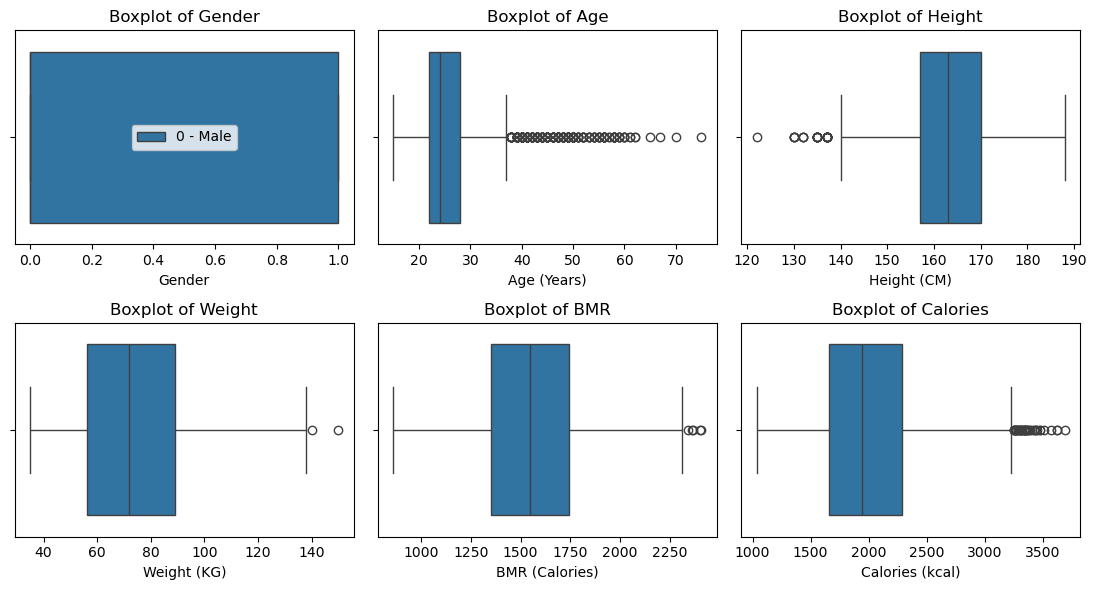

In [5]:
fig, axes = plt.subplots(2,3,figsize=(11,6))

sns.boxplot(x=df['Gender'],ax=axes[0,0])
axes[0,0].set_title("Boxplot of Gender")
axes[0,0].set_xlabel("Gender")
axes[0,0].legend(["0 - Male","1 - Female"])

sns.boxplot(x=df['Age'],ax=axes[0,1])
axes[0,1].set_title("Boxplot of Age")
axes[0,1].set_xlabel("Age (Years)")

sns.boxplot(x=df['Height'],ax=axes[0,2])
axes[0,2].set_title("Boxplot of Height")
axes[0,2].set_xlabel("Height (CM)")

sns.boxplot(x=df['Weight'],ax=axes[1,0])
axes[1,0].set_title("Boxplot of Weight")
axes[1,0].set_xlabel("Weight (KG)")

sns.boxplot(x=df['BMR'],ax=axes[1,1])
axes[1,1].set_title("Boxplot of BMR")
axes[1,1].set_xlabel("BMR (Calories)")

sns.boxplot(x=df['Calories'],ax=axes[1,2])
axes[1,2].set_title("Boxplot of Calories")
axes[1,2].set_xlabel("Calories (kcal)")

plt.tight_layout()
plt.show()


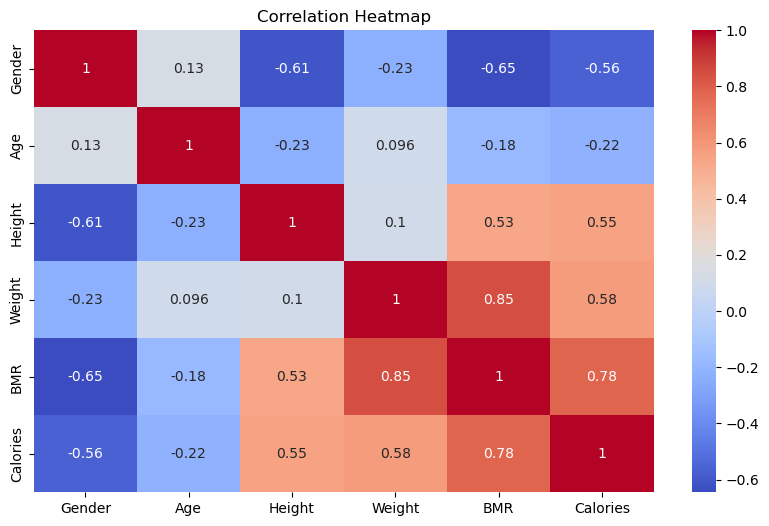

In [6]:
corr = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Features and Target

In [7]:
# Dependent Variable : Gender, Age, Height, Weight, BMR, Carbs, proteins, Fats
# Independet Variable : Calories

# X = df[["Gender", "Age", "Height", "Weight"]]   # independent variables
# Y = df[["Carbs", "Proteins", "Fats", "Calories"]]  # dependent variables

In [8]:
# X = df[['Gender', 'Age', 'Height', 'Weight', 'BMR', 'Carbs', 'Proteins', 'Fats']]


X = df[['Gender', 'Age', 'Height', 'Weight', 'BMR']]
Y = df['Calories']

# Traning Dataset And Testing Dataset

In [9]:
X_train, X_test, Y_train,Y_test = train_test_split( X, Y, test_size = 0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1745, 5)
Testing data shape: (437, 5)


# Standardization

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Pipeline

In [11]:
# print("\nTraining Linear Regression...")
# lr_pipeline.fit(X_train, Y_train)

# print("Training SVM Regression (SVR)...")
# svr_pipeline.fit(X_train, Y_train)

# KNN

In [12]:
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, Y_train)

KNeighborsRegressor()

In [13]:
# Predict
y_pred_knn = knn_model.predict(X_test)

In [14]:
# Compute metrics for SVM Regression
r2_knn = r2_score(Y_test, y_pred_knn)
mse_knn = mean_squared_error(Y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(Y_test, y_pred_knn)
within_tol_knn = np.abs(Y_test - y_pred_knn) <= 0.10 * np.abs(Y_test)
accuracy_pct_knn = 100.0 * np.mean(within_tol_knn)

In [15]:
print("\nKNN Regression")
print(f"  R²       : {r2_knn:.4f}")
print(f"  RMSE     : {rmse_knn:.4f}")
print(f"  MAE      : {mae_knn:.4f}")
print(f"  ACCURACY : {accuracy_pct_knn:.2f}% ({within_tol_knn.sum()}/{len(Y_test)})")


KNN Regression
  R²       : 0.6524
  RMSE     : 264.7660
  MAE      : 166.0031
  ACCURACY : 70.48% (308/437)


In [16]:
print("\n--- Predict Calories from Custom Input ---")
sample_gender = 0
sample_age    = 16
sample_height = 157
sample_weight = 73
sample_bmr    = 1636.25


# Create DataFrame
sample = pd.DataFrame([[sample_gender, sample_age, sample_height, sample_weight, sample_bmr]],
                      columns=['Gender','Age','Height','Weight','BMR'])
sample_scaled = scaler.transform(sample)

pred_knn = knn_model.predict(sample_scaled)[0]

print(f"\nInput: Gender={sample_gender}, Age={sample_age}, Height={sample_height}, Weight={sample_weight}, BMR={sample_bmr}")
print(f"Predicted Calories (KNN)              : {pred_knn:.2f}")



--- Predict Calories from Custom Input ---

Input: Gender=0, Age=16, Height=157, Weight=73, BMR=1636.25
Predicted Calories (KNN)              : 2132.63


# Plotting

### 1️. Predicted vs Actual

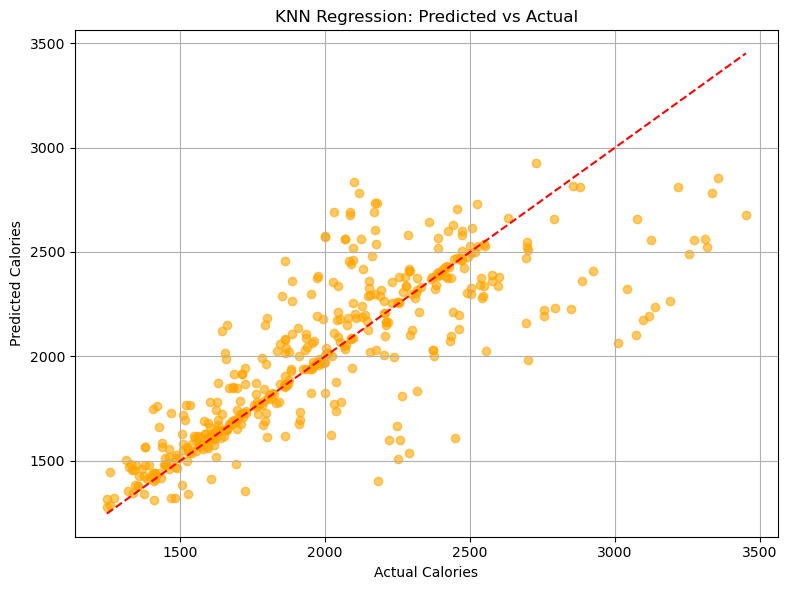

In [17]:
import matplotlib.pyplot as plt

# 3️⃣ KNN Regression
plt.figure(figsize=(8,6))
plt.scatter(Y_test, y_pred_knn, color='orange', alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('KNN Regression: Predicted vs Actual')
plt.grid(True)

plt.tight_layout()
plt.show()


### Residuals (Actual - Predicted)

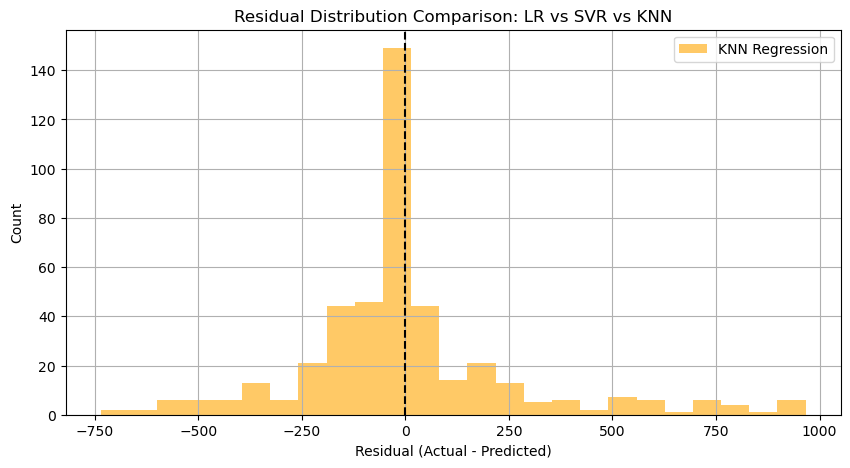

In [18]:

residuals_knn = Y_test - y_pred_knn

# Plot residual histograms
plt.figure(figsize=(10,5))
plt.hist(residuals_knn, bins=25, alpha=0.6, label='KNN Regression', color='orange')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Residual Distribution Comparison: LR vs SVR vs KNN')
plt.legend()
plt.grid(True)
plt.show()


### Residuals vs Predicted

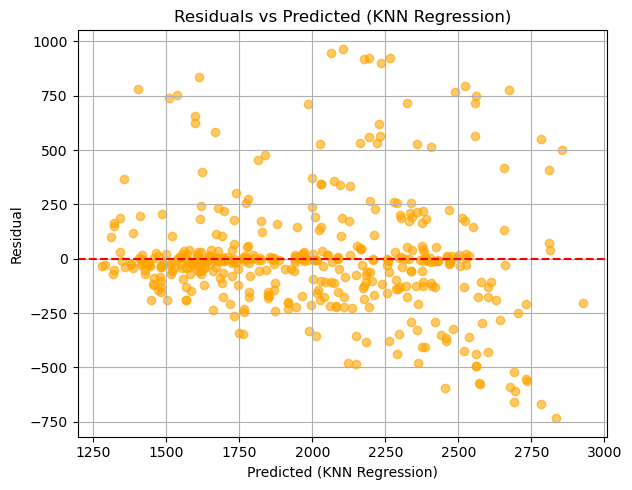

In [19]:
plt.figure(figsize=(18,5))

# 3️⃣ KNN Regression
plt.subplot(1,3,3)
plt.scatter(y_pred_knn, residuals_knn, color='orange', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted (KNN Regression)')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted (KNN Regression)')
plt.grid(True)

plt.tight_layout()
plt.show()
